## Part 0｜金融資料與特徵工程基礎

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
np.random.seed(42)

**載入 2327 日線資料**

用 `yfinance` 線上抓 `2327.TW` 的日線資料（自 2010-01-01起）。



In [23]:
stock = yf.download('2327.TW', start='2010-01-01', progress=False,
          auto_adjust=True)
stock

# 因為目前抓下的資料是多層索引的型別，所以我們要執行攤平欄的動作
if isinstance(stock.columns, pd.MultiIndex):
  stock.columns = stock.columns.get_level_values(0)
stock = stock[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
stock

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,5.108907,5.232013,4.975542,5.129425,18011183
2010-01-05,5.190978,5.344860,5.037095,5.129425,18133749
2010-01-06,5.211495,5.324343,5.170460,5.283308,13247328
2010-01-07,5.283308,5.324344,5.129425,5.149942,13566970
2010-01-08,5.211495,5.211495,5.037094,5.108906,6684407
...,...,...,...,...,...
2026-07-08,906.000000,930.000000,856.000000,891.000000,67677034
2026-07-09,915.000000,948.000000,900.000000,900.000000,49819016
2026-07-10,900.000000,900.000000,900.000000,900.000000,0


### ⚠️ 為什麼預測報酬率，不預測價格
- **價格是非定態序列**：有明顯趨勢，直接拿來迴歸會得到虛高的 R²（其實只是抓到趨勢自相關）。
- **報酬率近似定態**：去除了趨勢，才是有意義、可比較的預測目標。

### 📖 白話版：定態 vs 非定態

**「非定態」是什麼？** 想像一個人的**身高**：從出生到成年一路往上長，沒有固定的中心值——
嬰兒 50 公分、青少年 160、成年 175，它的「平均位置」一直在漂移。這種「統計特性隨時間改變」
的序列就是**非定態**。股價正是如此：台積電 2018 年在 200 元晃、2024 年在 900 元晃，
沒有穩定的中心價位，一路往上飄 → 價格是**非定態**。

**「虛高的 R²」是什麼意思？** 若你用「昨天的股價」預測「今天的股價」，R² 會高到接近 1、
看似神準。但它什麼都沒學到——今天股價本來就約等於昨天再加減一點。模型只是在說
「明天跟今天差不多」，這是一句**廢話**。這種「準得漂亮、其實沒用」的高 R² 就叫**虛高**，
成因是價格自己跟自己的過去高度相關（**趨勢自相關**）。

**為什麼改用報酬率？** 報酬率 = 今天相對昨天**漲跌百分之幾**。回到身高的比喻，這像是不看
「身高」而看「**今年長高幾公分**」：這數字在 0 附近上下跳，長期沒有往上飄 → **近似定態**。
能預測報酬率，才是真的抓到「漲跌規律」，而非「股價長期會變高」這種人人都知道的廢話。

> 一句話：**用價格預測價格，準得像作弊、其實沒用；用特徵預測報酬率，難得要命、但才有意義。**

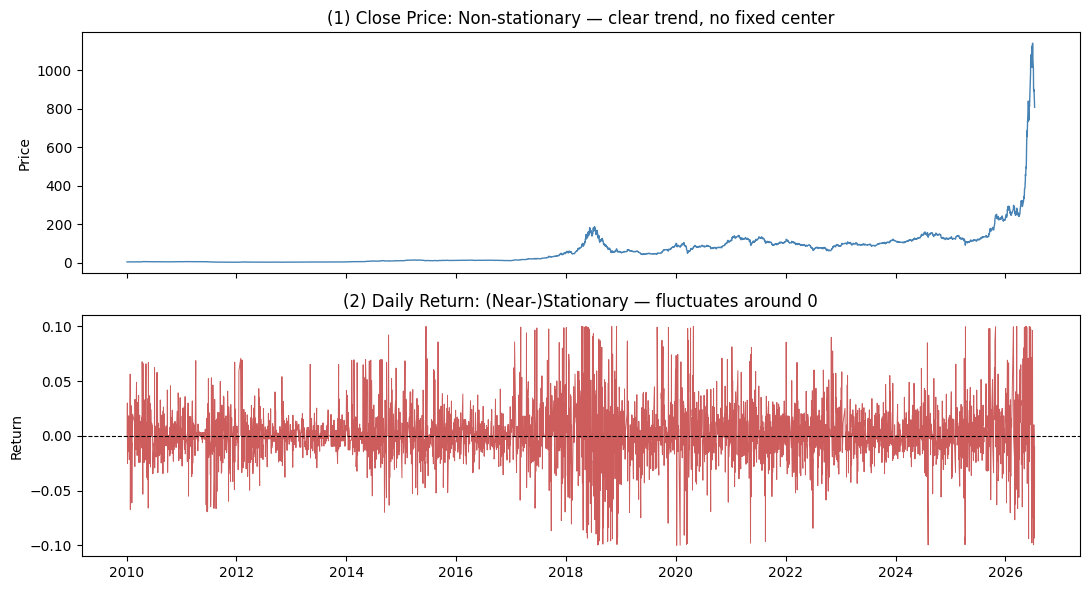

In [24]:
# Price (non-stationary, trending up) vs Return (near-stationary, around 0)
if "ret" not in stock.columns:
    stock["ret"] = stock["Close"].pct_change(fill_method=None)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax[0].plot(stock.index, stock["Close"], color="steelblue", lw=1)
ax[0].set_title("(1) Close Price: Non-stationary — clear trend, no fixed center")
ax[0].set_ylabel("Price")

ax[1].plot(stock.index, stock["ret"], color="indianred", lw=0.7)
ax[1].axhline(0, color="black", lw=0.8, ls="--")
ax[1].set_title("(2) Daily Return: (Near-)Stationary — fluctuates around 0")
ax[1].set_ylabel("Return")

plt.tight_layout()
plt.show()

In [25]:
# 建構目標變數:次日的報酬率
# 1.計算每日報酬率 ret = (今天的收盤價-昨天的收盤價) / 昨天的收盤價
# pct_change():自動幫你用(當列的數值 - 前一列的數值) / 前一列的數值，目的是為了計算百分比變化
# fill_method=None，不對缺值做向前填補，而是直接補NnN，缺值的原因是來自於第一列沒有昨天，所以ret會是NaN
stock['ret'] = stock['Close'].pct_change(fill_method=None)
stock.head()

# 2. 計算次日報酬率
# shift(-1):他是把整個Series往上移一格，也就是說把明天的ret拉到今天的這一列
# 它的意義代表我們可以用今天含以前的所有資料來預測明天的報酬
# 為什麼target的最後一列是NaN，因為明天的資料還不存在
# 一定把明天的報酬拉到今天的這一列，因為所有的特徵都只能用今天含以前的資訊，不然就是偷看答案
stock['target'] = stock['ret'].shift(-1)
stock.tail()

Price,Open,High,Low,Close,Volume,ret,target
Date,,,,,,,
2026-07-08,906.0,930.0,856.0,891.0,67677034,-0.015470,0.010101
2026-07-09,915.0,948.0,900.0,900.0,49819016,0.010101,0.000000
2026-07-10,900.0,900.0,900.0,900.0,0,0.000000,-0.093333
2026-07-13,921.0,921.0,810.0,816.0,67936028,-0.093333,-0.009804
2026-07-14,798.0,808.0,797.0,808.0,3112000,-0.009804,NaN


## Part 1｜線性迴歸
### 使用技術指標當作特徵

In [26]:
# !pip install ta-lib
import talib

stock['rsi14'] = talib.RSI(stock['Close'], 14)
macd, signal, hist = talib.MACD(stock['Close'], 12, 26, 9)
stock['macd_hist'] = hist

slowk, slowd = talib.STOCH(stock['High'], stock['Low'], stock['Close'],
                14, 3, 0, 3, 0)
stock['stoch_k'] = slowk
stock['atr'] = talib.ATR(stock['High'], stock['Low'], stock['Close'], 14)
up, middle, lo = talib.BBANDS(stock['Close'], 20, 2, 2)
stock['bb_pctb'] = (stock['Close'] - lo) / (up - lo)
stock['vol_ratio'] = stock['Volume'] / talib.SMA(stock['Volume'], 20) - 1
stock
data = stock.dropna().copy()
data.head()

Price,Open,High,Low,Close,Volume,ret,target,rsi14,macd_hist,stoch_k,atr,bb_pctb,vol_ratio
Date,,,,,,,,,,,,,
2010-03-01,4.780623,4.821658,4.688293,4.739588,6930078,-0.008584,0.004329,44.631169,0.018003,37.387423,0.176459,0.358838,-0.022895
2010-03-02,4.780624,4.862694,4.760106,4.760106,10594083,0.004329,0.008621,45.604198,0.020200,43.243286,0.172648,0.408147,0.451510
2010-03-03,4.780624,4.821659,4.760106,4.801142,4746577,0.008621,-0.012821,47.588055,0.024285,48.980633,0.164713,0.521150,-0.311109
2010-03-04,4.801141,4.862694,4.739588,4.739588,6365844,-0.012821,0.017316,44.940430,0.022738,54.335049,0.161741,0.391836,-0.035184
2010-03-05,4.801140,4.893470,4.780623,4.821658,6234640,0.017316,0.048936,49.013537,0.026855,68.068668,0.161179,0.582622,-0.056359


### ⚠️ 時間序列不能隨機切分
隨機 `shuffle` 會把未來的資料混進訓練集 → 用未來預測過去 → look-ahead。
金融資料一律用**時間順序切分**：前 80% 訓練、後 20% 測試。

In [27]:
from sklearn.linear_model import LinearRegression

# 準備我的題目和答案
# 題目就是6個技術指標，答案就是明天漲跌是多少
data
feat = ['rsi14', 'macd_hist', 'stoch_k', 'atr', 'bb_pctb', 'vol_ratio']
X = data[feat] # 題目
y = data['target'] # 答案

# 照時間把資料切成模擬考卷跟正式考卷
# 千萬不能隨機打散資料，因為怕你把還沒考的未來題目偷混進去模擬考卷，作弊

split_data = '2024-07-01'
train_data = data.index < split_data # 模擬考卷-訓練資料
test_data = data.index >= split_data # 正式考卷-測試資料

X_train, X_test = X[train_data], X[test_data]
y_train, y_test = y[train_data], y[test_data]

# 將模擬考卷和正式考卷印出來看一下各幾筆並且確認日期範圍對不對
print(f'切分日 {split_data}')
print(f'模擬考卷 {len(X_train)} 筆 {X_train.index.min().date()} ~ {X_train.index.max().date()}' )
print(f'正式考卷 {len(X_test)} 筆 {X_test.index.min().date()} ~ {X_test.index.max().date()}')

# 訓練最基本的線性迴歸OLS，線性迴歸主要就是找一條線，讓預測值和真實答案的落差平方總和最小
# 拿出一把尺，找出一條最貼近所有點的直線
lr = LinearRegression().fit(X_train, y_train) # 透過fit來讀練習卷學習資料規律

# 看成績R2，R2接近1代表很準，接近0代表跟亂猜差不多，等於沒有學到東西，小於0比亂猜來要爛

print(f'OLS測試集 R2: {round(lr.score(X_test, y_test), 3)}')

切分日 2024-07-01
模擬考卷 3513 筆 2010-03-01 ~ 2024-06-28
正式考卷 492 筆 2024-07-01 ~ 2026-07-13
OLS測試集 R2: -0.15


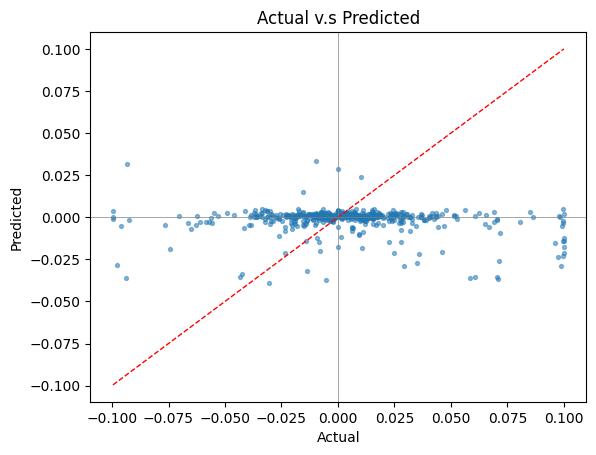

In [28]:
# 第一部分:把實際值跟預測值進行排列並做表格

y_pred = lr.predict(X_test)

compare = pd.DataFrame({'實際值':y_test, '預測值':y_pred, '誤差':y_test-y_pred},
            index=X_test.index)
compare


# 第二部分:實際值跟預測值畫成散點圖加上45度完美預測線
plt.scatter(y_test, y_pred, s=8, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=1, label='perfect prediction (y = x)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.title('Actual v.s Predicted')
plt.show()


R² 接近 0 或為負是**預期結果**，代表這些簡單技術指標對次日報酬
幾乎沒有線性預測力。

In [29]:
pd.Series(lr.coef_, index=feat).sort_values()
data[feat].corr().round(2)

Price,rsi14,macd_hist,stoch_k,atr,bb_pctb,vol_ratio
Price,,,,,,
rsi14,1.00,0.29,0.82,0.13,0.89,0.20
macd_hist,0.29,1.00,0.31,0.02,0.28,0.04
stoch_k,0.82,0.31,1.00,0.06,0.87,0.17
atr,0.13,0.02,0.06,1.00,0.05,0.00
bb_pctb,0.89,0.28,0.87,0.05,1.00,0.28
vol_ratio,0.20,0.04,0.17,0.00,0.28,1.00


## 📝 練習題：新增特徵 × 誠實基準對照

**情境**
你在課堂上已經用 6 個技術指標對 2327 建了 OLS 迴歸，發現測試集 R² 是負的。
這一題要你動手驗證兩件事：**(a) 多加一個特徵能不能救回 R²？(b) 你的模型到底有沒有贏過「無腦亂猜」？**

> **前置**：接續本 notebook，`data`、`feat`、時間切分（`split_data = '2024-07-01'`）都已存在。

### 任務

1. **新增一個技術指標特徵**，且必須**無 look-ahead**（只能用今天含以前的資訊）。三選一或自選：
   - 乖離率 `ma_gap = Close / SMA(Close, 20) − 1`
   - 5 日動量 `mom5 = Close.pct_change(5)`
   - 威廉指標 `willr = talib.WILLR(High, Low, Close, 14)`

2. 把新特徵加進 `feat`，用**同一個時間切分**重跑 OLS，印出新的 R²，並和原本 6 特徵的 R² 比較。
3. **建立「笨基準」對照**：用「一律猜訓練集平均報酬率」當預測，計算它的 MSE，
   再和你模型的 MSE 比較，回答：**你的模型有沒有贏過亂猜？**

4. 用 2–3 行**誠實結論**說明：加了特徵後 R² 是否改善？模型是否勝過笨基準？這代表什麼？

In [30]:
from sklearn.metrics import mean_squared_error
# 產生新的特徵加入至data後，進行空值得刪除
data['ma_gap'] = data['Close'] / talib.SMA(data['Close'], 20) - 1
data = data.dropna().copy()
data

# 把新的特徵加入訓練特徵內
feat_new = ['rsi14', 'macd_hist', 'stoch_k', 'atr', 'bb_pctb', 'vol_ratio', 'ma_gap']
X, y = data[feat_new], data['target']

# 用同一個時間進行資料切分
split_data = '2024-07-01'
train_data = data.index < split_data # 模擬考卷-訓練資料
test_data = data.index >= split_data # 正式考卷-測試資料

X_train, X_test = X[train_data], X[test_data]
y_train, y_test = y[train_data], y[test_data]

# 開始訓練模型
lr = LinearRegression().fit(X_train, y_train)

# 評估模型效能的R2
print(f'加入新的特徵後的R2 {round(lr.score(X_test, y_test), 3)}')

# 建立所謂的笨基準
# 笨基準代表完全不看特徵，測試集每一天都在猜訓練集的平均報酬率
# np.full(長度, 填充值):做一個跟y_test相同長度和值一樣的陣列
baseline_pred = np.full(len(y_test), y_train.mean())

mse_baseline = mean_squared_error(y_test, baseline_pred)
mse_model = mean_squared_error(y_test, lr.predict(X_test))
print(f'笨基準的MSE: {mse_baseline:.4f}')
print(f'模型的MSE: {mse_model:.4f}')
print(f'模型贏過笨基準了嗎? {mse_model < mse_baseline}')

from sklearn.metrics import r2_score
r2_baseline = r2_score(y_test, baseline_pred)
model_pred = lr.predict(X_test)
r2_model = r2_score(y_test, model_pred)
print(f'笨基準的R2: {r2_baseline:.4f}')
print(f'模型的R2: {r2_model:.4f}')

加入新的特徵後的R2 -0.165
笨基準的MSE: 0.0011
模型的MSE: 0.0013
模型贏過笨基準了嗎? False
笨基準的R2: -0.0070
模型的R2: -0.1653


結論

1. 加入ma_gap後，R2本身並沒有改善，仍接近於0，甚至是負的
2. 模型MSE>笨基準的MSE，沒有贏過亂猜
3. 多加技術指標也救不了次日報酬率，問題出在資料沒有訊號，不是特徵不夠多。

## Part 2｜正則化動機與 Ridge 迴歸（2h）

### OLS 為什麼會「用力過猛」
OLS 只有一個目標：把訓練資料擬合到最好。當特徵很多、或特徵之間高度重複（共線）時，
它會為了多擠出一點準度，把某些權重開得又大又極端——結果是**把訓練資料的雜訊也當成規律學了進去**。
這種模型在練習卷上很漂亮，一換成正式考卷就崩掉，也就是**過擬合**。

> 打個比方：OLS 像一個死背考古題的學生，連題目印錯的地方都背下來，
> 遇到新題目反而答不出來。

### Ridge：幫權重「踩剎車」
Ridge 在 OLS 原本的目標上，多加一條規矩：**「權重開太大要罰分」**。
於是模型不能再毫無節制地衝準度，得在「擬合資料」和「權重不要太誇張」之間取得平衡。

$$\text{要最小化的總分} = \underbrace{\text{預測誤差}}_{\text{原本就要顧}} + \;\alpha \times \underbrace{\text{所有權重的平方和}}_{\text{新增的罰則}}$$

- **α 是罰得多重的旋鈕**：
  - α 越大 → 罰越兇 → 權重被壓得越小、模型越保守。
  - α = 0 → 完全不罰 → 退回原本的 OLS。
  - α 非常大 → 權重全被壓到趨近 0（但**不會剛好等於 0**）。

> 對照 Lasso：Ridge 是「大家一起小聲一點」，把權重**通通縮小但都保留**；
> Lasso 才會「直接叫沒用的閉嘴」，把權重壓成剛好 0。這是兩者最大的差別。

In [31]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Ridge就是OLS+一條規定:[權重不准開太大]，控制權是由alpha係數控制，也就是alpha如果小，管很鬆
# alpha如果大，管很嚴，權重壓小但不會壓到0

ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_train, y_train)
print(f'Ridge 測試集 R2: {ridge.score(X_test, y_test):.4f}')

Ridge 測試集 R2: -0.1651


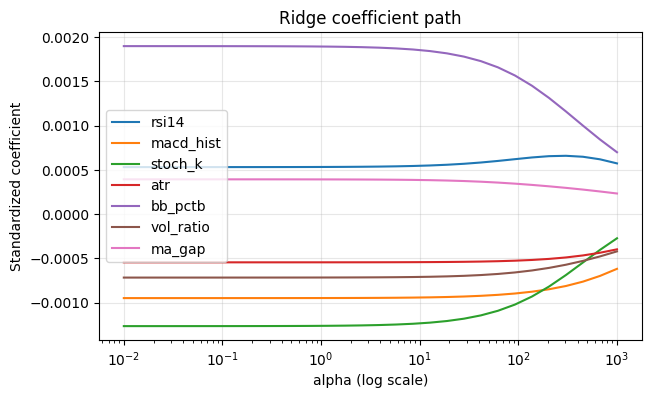

In [32]:
# 要來畫一張圖，這張圖會呈現alpha越大，權重被壓得越小的過程

alphas = np.logspace(-2, 3, 30) # 從0.01到1000，取30個等比放大的數值
# 使用每一個alpha來各自訓練一個Ridge，取出訓練後的6個權重
coefs = [make_pipeline(StandardScaler(), Ridge(alpha=a)).fit(X_train, y_train)
    [-1].coef_ for a in alphas]
coefs

plt.figure(figsize=(7, 4))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Standardized coefficient')
plt.title('Ridge coefficient path')
plt.legend(feat_new)
plt.grid(alpha=0.3)
plt.show()

### 📊 如何解讀這張 Ridge 係數路徑圖
這張圖用一張圖同時展示「α 這個旋鈕怎麼影響 7 個特徵的權重」。

**怎麼讀**
- **X 軸**：α（log 尺度，0.01 → 1000）＝「罰得多重的旋鈕」，越往右罰越兇。
- **Y 軸**：標準化後的係數（權重）。正值=助漲、負值=助跌、越接近 0=影響越小。
- **每條線**：一個特徵，看它從左走到右權重怎麼被「壓」。

**這張圖在說三件事**

**1. α 越大，所有線都往中間（0）收——但沒有任何一條真的碰到 0**
左邊（α 小、幾乎不罰）每條線各有高度；往右（α 變大、罰越重）全部往 0 靠攏，
到 α=1000 時擠在 0 附近。這印證了「α 越大→權重被壓得越小，但**不會剛好等於 0**」——
這正是 Ridge 與 Lasso 的分水嶺（Lasso 會有線真的貼到 0）。

**2. 每個特徵「撐多久才被壓下去」不一樣，反映它的相對重要性**
- `bb_pctb`（紫）與 `ma_gap`（粉）起點絕對值最大，撐到 α≈10 之後才明顯下掉
  → Ridge 認為它們相對重要，捨不得太早壓。
- `vol_ratio`（棕）從頭到尾貼在 0 附近、幾乎水平
  → 它本來影響就極小（呼應相關矩陣：vol_ratio 與報酬幾乎不相關），罰不罰都沒差。

**3. 左半邊全是平的——這才是最重要的線索**
α 從 0.01 到約 1（圖的左半）幾乎所有線都水平沒動：
代表在這份資料上，**加不加一點點正則化，係數幾乎不變、模型也不會更好**。

> ### ⚠️ 這張圖對本題的真正結論
> 別被漂亮的曲線騙了——回頭看 **Y 軸的數量級：所有係數都落在 ±0.0018 這種極小範圍**。
> 也就是說，7 個特徵不管怎麼調 α，對次日報酬的權重全都微乎其微。
>
> **次日報酬幾乎沒有訊號，Ridge 能做的只是「把本來就很小的權重再壓小一點」，
> 它救不了「資料本身沒東西可學」這件事。**
>
> 正則化解決的是「特徵太多／共線導致權重亂衝」的問題，它**不能無中生有**製造出
> 不存在的預測力。這張圖展示了 Ridge 的**機制**（α 如何收縮係數），但也誠實地告訴你：
> 在這份資料上，它改變不了 **R²≈0** 的命運。

### 用時間序列 CV 選 alpha
不能用隨機 `KFold`；改用 `TimeSeriesSplit`：每一折都「用過去訓練、預測未來」。

In [33]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# 問題:到底alpha要設多少才好?
# 總不能自己亂猜，所以最適做法是讓模型自我模擬考很多組alpha，挑成績好的那一組

# TimeSeriesSplit:照時間來排模擬考
# 把練習卷切成好幾回的小練習+小測驗，而且永遠都是拿前面考後面
# 舉例:第1回:拿1~200天進行練習，考201~400天
# 第2回:拿1~400天進行練習，考401~600天

tsvc = TimeSeriesSplit(n_splits=5)

# GridSearchCV:把每個alpha都拿去模擬考，挑最高分
# 工作流程:對list裡面的每一個alpha都用上面那套5回模擬考試算平均分，最後選平均分最高的alpha

grid = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
          {'ridge__alpha':np.logspace(-2, 3, 20)},
          cv=tsvc, scoring='r2')
grid.fit(X_train, y_train)
print(f'模擬考選出最佳的alpha: {grid.best_params_['ridge__alpha']:.3f}')


模擬考選出最佳的alpha: 1000.000


當資料近乎不可預測時，CV 往往選出**很大的 alpha**（重度收縮、
近乎不相信任何特徵）。這本身就是一個誠實的訊號：模型在說「這些因子沒什麼用」。


## Part 3｜Lasso、ElasticNet 與特徵選擇（2.5h）

### Lasso：會「直接刪掉沒用特徵」的正則化
Lasso 跟 Ridge 一樣會罰「權重開太大」，但罰法不同——
它會把**沒用的特徵權重壓成「剛好 0」**，等於直接把那個特徵踢出模型。

$$\text{要最小化的總分} = \underbrace{\text{預測誤差}}_{\text{原本就要顧}} + \;\alpha \times \underbrace{\text{所有權重的絕對值總和}}_{\text{新增的罰則}}$$

跟 Ridge 的差別只在罰則那一項：

| | 罰則怎麼算 | 對權重的效果 |
|---|-----------|-------------|
| **Ridge** | 權重的**平方**和 | 通通縮小，但**都保留**（不會變 0） |
| **Lasso** | 權重的**絕對值**和 | 沒用的**直接歸零**、被刪掉 |

> 白話比喻：Ridge 是「全班一起小聲一點」，Lasso 是「叫沒在講重點的人**直接閉嘴**」。

**所以 Lasso 等於順便幫你挑重點**：跑完之後，權重**還留著（≠0）的特徵，就是它認為真正有用的**；
被壓成 0 的，它覺得可以丟掉。這讓 Lasso 特別適合回答一個問題——
**「這一堆因子裡，到底哪幾個才真的有用？」**

In [34]:
from sklearn.linear_model import Lasso

# alpha定義跟Ridge近似一樣，alpha太大，管很嚴，所有指標會被刪光
# alpha太小，管很鬆，所有指標幾乎會留著
# max_iter=10000
# Lasso是採用一步步試著逼近答案的算法，我們會把上限提高，避免他還沒有算完之後就中途喊停
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.0002, max_iter=10000)).fit(X_train, y_train)

pd.Series(lasso[-1].coef_, index=feat_new)

,0
rsi14,0.000525
macd_hist,-0.000519
stoch_k,-0.000000
atr,-0.000300
bb_pctb,0.000630
vol_ratio,-0.000317
ma_gap,0.000000


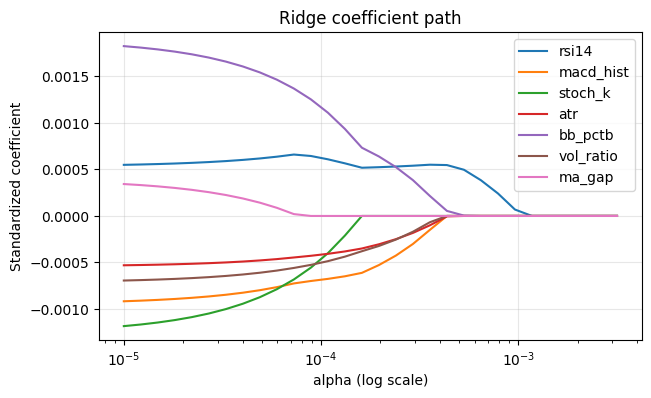

In [35]:
# 要來畫一張圖，這張圖會呈現alpha越大，權重被壓得越小的過程

alphas_1 = np.logspace(-5, -2.5, 30) # 從0.01到1000，取30個等比放大的數值
# 使用每一個alpha來各自訓練一個Ridge，取出訓練後的6個權重
coefs_1 = [make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000)).fit(X_train, y_train)
    [-1].coef_ for a in alphas_1]
coefs

plt.figure(figsize=(7, 4))
plt.plot(alphas_1, coefs_1)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Standardized coefficient')
plt.title('Ridge coefficient path')
plt.legend(feat_new)
plt.grid(alpha=0.3)
plt.show()

## 📝 練習題：Ridge vs Lasso 三方對決

**情境**
你已經看過 Ridge 和 Lasso 的係數路徑圖，知道正則化會壓縮係數、Lasso 還會把沒用的特徵歸零。
現在動手驗證三件事：**(a) 正則化能不能把 R² 救回正的？(b) 該用多大的 alpha？(c) Lasso 到底幫你選了哪些特徵、可不可信？**

> **前置**：接續本 notebook，`data`、`feat_new`（7 個特徵）、`split_data='2024-07-01'` 都已存在。

### 任務

1. **三方對決**：用**同一個時間切分**，比較 `OLS` / `Ridge(alpha=1.0)` / `Lasso(alpha=0.0002)` 三者的測試集 R²。
   ⚠️ Ridge 和 Lasso 一定要包 `StandardScaler`，OLS 不用——**先想清楚為什麼**。

2. **幫 Ridge 選 alpha**：用 `TimeSeriesSplit(5)` + `GridSearchCV` 搜尋最佳 alpha（範圍 `np.logspace(-2, 3, 20)`），印出**最佳 alpha** 與它的測試集 R²。
   ⚠️ Pipeline 的參數名是 `ridge__alpha`（**兩條底線**）。

3. **看 Lasso 選了誰**：印出 Lasso 的各特徵係數，列出**係數非零（被選中）**的特徵有哪些、共幾個。

4. **誠實結論**（2–3 行）：三方 R² 有明顯差別嗎？GridSearch 選出的 alpha 偏大還偏小、代表什麼？Lasso 選出的特徵**可信嗎**（提示：看係數的量級）？

In [36]:
X, y = data[feat_new], data['target']
train = data.index < split_data
test = data.index >= split_data
X_train, X_test = X[train], X[test]
y_train, ytest = y[train], y[test]

# 任務1:三方對決
ols = LinearRegression().fit(X_train, y_train)
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_train, y_train)
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.0002, max_iter=10000)).fit(X_train, y_train)

for name, m in [('OLS', ols), ('Ridge', ridge), ('Lasso', lasso)]:
  print(f'{name} R2: {m.score(X_test, y_test):.4f}')

# 任務2:GridSearch選alpha
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
          {'ridge__alpha':np.logspace(-2, 3, 20)},
          cv=tsvc, scoring='r2')
grid.fit(X_train, y_train)
print(f'選出最佳的alpha: {grid.best_params_['ridge__alpha']:.3f}')
print(f'最佳的alpha之測試R2: {grid.score(X_test, y_test):.4f}')

# 任務3:Lasso選了誰
coef = pd.Series(lasso[-1].coef_, index=X_train.columns)
kept = coef[coef != 0].index.tolist()
print(f'Lasso保留的特徵: {kept}, 共 {len(kept)} 個')
print(coef)

# 任務4:結論
# 1. 三個模型的R2幾乎相同，但因為都是趨近於0，所以正則化這件事情沒有效用，也沒有辦法改變模型的預測能力
# 2. Gridsearch選出的Alpha值很大，十字交叉驗證這個動作認為要重罰，等同於不相信任何的特徵，所以也就代表說這些特徵
# 本身對預測報酬率這件事情是沒有預測力的
# 3. Lasso雖然留下幾個特徵，但數字小到已經快要趨近於0，所以這些特徵是沒有用的

OLS R2: -0.1653
Ridge R2: -0.1651
Lasso R2: -0.0785
選出最佳的alpha: 1000.000
最佳的alpha之測試R2: -0.0963
Lasso保留的特徵: ['rsi14', 'macd_hist', 'atr', 'bb_pctb', 'vol_ratio'], 共 5 個
Price
rsi14        0.000525
macd_hist   -0.000519
stoch_k     -0.000000
atr         -0.000300
bb_pctb      0.000630
vol_ratio   -0.000317
ma_gap       0.000000
dtype: float64


### Ridge vs Lasso：兩種「罰法」的差別

前面兩張路徑圖已經看過差別，這裡做個總整理：

| | 怎麼罰 | 結果 | 什麼時候用它 |
|---|--------|------|-------------|
| **Ridge** | 罰「權重的平方」 | 所有權重一起變小，但**都留著、不會變 0** | 覺得每個特徵都有點用、或特徵彼此很像（共線）時 |
| **Lasso** | 罰「權重的絕對值」 | 把沒用的權重**直接壓成 0、踢出去** | 想讓模型幫你**挑重點**、只留少數關鍵特徵時 |

> 一句話：**Ridge 是「大家一起小聲」，Lasso 是「叫沒用的閉嘴」。**

### ElasticNet：把 Ridge 和 Lasso「各取一半」

ElasticNet 就是**同時用上 Ridge 和 Lasso 兩種罰法**，用一個叫 `l1_ratio` 的旋鈕決定「比較像誰」：

- `l1_ratio = 0` → 完全是 Ridge（只縮小、不歸零）
- `l1_ratio = 1` → 完全是 Lasso（會歸零、挑特徵）
- 中間值 → 兩者的混合

**為什麼需要這個折衷？** 因為 Lasso 有個小毛病：**當好幾個特徵長得很像（共線）時，它會很任性地在裡面隨便只留一個、其他全刪**——但被刪的那些其實一樣有用，只是剛好跟留下來的那個很像而已。這樣選出來的結果不穩定，換一批資料可能又選到別的。

ElasticNet 靠著混入 Ridge 的成分修正了這點：**遇到一群長得很像的特徵，它傾向「整群一起保留」或「整群一起縮小」，而不是硬挑一個、砍掉其他**。所以在你這種技術指標高度共線的情況（`rsi14`、`stoch_k`、`bb_pctb` 那一群），ElasticNet 通常比純 Lasso 更穩、更可信。

In [46]:
from sklearn.linear_model import ElasticNetCV

# ElasticNetCV:進行一次考試選出最適的alpha和11_ratio，所以不用自己試，我們給了0.1, 0.5,
# 0.9, 1:給了4個比例讓他選
en =  make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1], cv=tscv,
            max_iter=10000)).fit(X_train, y_train)

print(f'選到的Alpha值: {en[-1].alpha_:.6f}') # 選出來的最適的Alpha值
print(f'選到的l1_ratio值: {en[-1].l1_ratio_:.6f}') # 選出來的最適的l1_ratio，
                          # 選出來的l1_ratio偏大，代表模型認為這組特徵用lasso會比較好
print(f'測試集R2: {en.score(X_test, y_test):.6f}')

選到的Alpha值: 0.000961
選到的l1_ratio值: 1.000000
測試集R2: -0.006449


## Part 5｜綜合練習：玉山金（2884）次日報酬預測

用**玉山金（2884）**的日線資料預測**次日報酬率**，把 U2 整章學到的招式全部用上，
最後產出一張**各模型的 MSE / R² 對照表**，並誠實判讀。

### 具體要求

1. **資料**：抓 2884 玉山金，區間 **2015-01-01 ~ 2026-07-13**（還原價）。
2. **目標**：`target = 次日報酬率`（今日收盤算報酬，`shift(-1)`）。
3. **特徵**：用 **talib 產生 10 個技術指標**（全部只用過去資料，無 look-ahead）。指定這 10 個：
   `rsi14`、`macd_hist`、`stoch_k`、`willr`、`cci`、`adx`、`atr_pct`、`bb_pctb`、`roc10`、`vol_ratio`。
4. **切分**：用**日期**切分——`split_date = '2023-01-01'`，該日之前訓練、之後測試，**不可隨機 shuffle**。
5. **模型**：跑本章所有招式——`OLS`、`Ridge`、`Lasso`、`ElasticNet`
   （後三者用 `StandardScaler` + `TimeSeriesSplit` 自動選 alpha）。
6. **基準**：加一條「猜訓練集平均」的笨基準當及格線。
7. **輸出**：一張表，列出**每個模型 + 笨基準**的**測試集 MSE 與 R²**。
8. **結論**：3–5 行誠實討論——有沒有模型明顯贏過笨基準？這代表什麼？

In [79]:
# !pip install ta-lib

import numpy as np
import pandas as pd
import yfinance as yf
import talib

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# 1. 使用yfinance抓取玉山金的資料(2015-01-01~2026-07-13，不含除權息的股價)
df = yf.download('2884.TW', start='2015-01-01', end='2026-07-14', auto_adjust=True, progress=False)
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
df

# 2. 設立目標:次日報酬率
df['ret'] = df['Close'].pct_change(fill_method=None)
df['target'] = df['ret'].shift(-1)
df.tail()

# 3. 使用talib產生10個特徵
H, L, C, V = df['High'], df['Low'], df['Close'], df['Volume']
df['rsi14'] = talib.RSI(C, 14)
df['macd_hist'] = talib.MACD(C, 12, 26, 9)[2]
df['stoch_k'] = talib.STOCH(H, L, C, 14, 3, 0, 3, 0)[0]
df['willr'] = talib.WILLR(H, L, C, 14)
df['cci'] = talib.CCI(H, L, C, 14)
df['adx'] = talib.ADX(H, L, C, 14)
df['atr_pct'] = talib.ATR(H, L, C, 14) / C
up, mid, lo = talib.BBANDS(C, 20, 2, 2)
df['bb_pcb'] = (C - lo) / (up - lo)
df['roc10'] = talib.ROC(C, 10)
df['vol_ratio'] = V / talib.SMA(V, 20) - 1

feat = ['rsi14', 'macd_hist', 'stoch_k', 'willr', 'cci', 'adx', 'atr_pct',
      'bb_pcb', 'roc10', 'vol_ratio']
data = df.dropna().copy()
data

# 4. 用日期切分訓練集和測試集
split_date = '2023-01-01'
train = data.index < split_date
test = data.index >= split_date
X, y = data[feat], data['target']
X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

print(f'切分日 {split_date}')
print(f'訓練集 {len(X_train)} 筆 {X_train.index.min().date()} ~ {X_train.index.max().date()}' )
print(f'測試集 {len(X_test)} 筆 {X_test.index.min().date()} ~ {X_test.index.max().date()}')

# 5. 準備模型
tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-3, 2, 20)
models = {'OLS':LinearRegression(),
      'Ridge':make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=tscv)),
      'Lasso':make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=tscv, max_iter=10000)),
      'ElasticNet': make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1,.5, .9, 1],
       alphas=alphas, cv=tscv, max_iter=10000))}
models

# 6. 建立笨基準
results = []
baseline = np.full(len(y_test), y_train.mean())
results.append(('笨基準', mean_squared_error(y_test, baseline), r2_score(y_test, baseline)))
results

# 7. 使用迴圈的方式訓練模型
for name, m in models.items():
  m.fit(X_train, y_train)
  pred = m.predict(X_test)
  results.append((name, mean_squared_error(y_test, pred), r2_score(y_test, pred)))

# 8. 製作呈現表格
table = pd.DataFrame(results, columns=['模型', '測試MSE', '測試R2']).set_index('模型')
table

切分日 2023-01-01
訓練集 1920 筆 2015-03-02 ~ 2022-12-30
測試集 847 筆 2023-01-03 ~ 2026-07-10


,測試MSE,測試R2
模型,,
笨基準,0.000126,-0.000169
OLS,0.000126,-0.006295
Ridge,0.000126,-0.002592
Lasso,0.000126,-0.000169
ElasticNet,0.000126,-0.000169
